In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import pandas as pd

In [2]:
# Specify the filename for the .pkl file
filename = "collision_stats_final.pkl"
# Load the dictionary back from the .pkl file
with open(filename, "rb") as f:
    stats = pickle.load(f)

# Specify the filename for the .pkl file
filename = "collision_stats_fcnn_final.pkl"
# Load the dictionary back from the .pkl file
with open(filename, "rb") as f:
    stats_fcnn = pickle.load(f)

In [3]:
iterations = list(stats.keys())
all_methods = list(stats[0].keys())
percentages = list(stats[0]['FES'].keys())
metrics = list(stats[0]['FES'][1.0].keys())

alpha_values = list(stats_fcnn[0].keys())

In [4]:
median_stats = {}
for method_key in all_methods:
    median_stats[method_key] = {}
    for percentage_key in percentages:
        median_stats[method_key][percentage_key] = {}
        for metric_key in metrics:
            median_stats[method_key][percentage_key][metric_key] = np.median([
            stats[iter][method_key][percentage_key][metric_key] 
            for iter in iterations 
            if stats[iter][method_key][percentage_key][metric_key] is not None
        ])  

In [17]:
fcnn_stats = {}
for iter in iterations:
    fcnn_stats[iter] = {}
    for alpha_key in alpha_values:
        fcnn_stats[iter][alpha_key] = stats_fcnn[iter][alpha_key]

## How does the reduction affects the efficiency?

In [18]:
reduction_ratio_fcnn = pd.DataFrame(index=['FCNN'], columns=alpha_values)
for iter in iterations:
    for alpha_key in alpha_values:
        reduction_ratio_fcnn.loc['FCNN', alpha_key] = round(fcnn_stats[iter][alpha_key],2)
reduction_ratio_fcnn_t = reduction_ratio_fcnn.transpose()

# Reset index to make alpha values a column
reduction_ratio_fcnn_t = reduction_ratio_fcnn_t.reset_index()
reduction_ratio_fcnn_t.columns = ['alpha', 'reduction_ratio']

# Visualizza il risultato
reduction_ratio_fcnn_t

,alpha,reduction_ratio
0,0.10,74.77
1,0.20,80.7
2,0.25,86.88
3,0.30,86.88
4,0.40,100.0


In [20]:
time_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        time_df.loc[m][p] = round(median_stats[m][p]['time'],2)
time_df_t = time_df.transpose()
time_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_27848\327068377.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df.loc[m][p] = round(median_stats[m][p]['time'],2)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,5251.15,52.76,78.07,64.09,67.9,55.55,251.28
0.3,4146.91,157.64,191.67,190.43,195.48,161.25,312.54
0.5,2948.22,262.78,303.96,310.28,318.43,267.66,374.7
0.7,2907.59,367.0,408.02,423.62,433.1,371.16,436.25
0.9,3.29,471.83,522.8,532.15,546.48,478.67,499.62
1.0,529.73,529.73,529.73,529.73,529.73,529.73,529.73


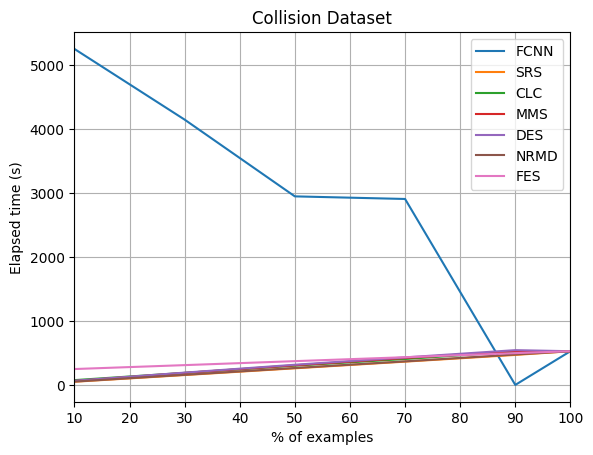

In [21]:
for idx, row in time_df.iterrows():
    plt.plot(time_df.columns * 100, row, label=idx)
plt.xlabel('% of examples')
plt.ylabel('Elapsed time (s)')
plt.title('Collision Dataset')
plt.xlim(10,100)
plt.grid()
plt.legend()
plt.show()

In [22]:
carbon_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        carbon_df.loc[m][p] = round(median_stats[m][p]['carbon'] * 1000,3)
carbon_df_t = carbon_df.transpose()
carbon_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_27848\171476848.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  carbon_df.loc[m][p] = round(median_stats[m][p]['carbon'] * 1000,3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,45.561,0.459,0.682,0.557,0.592,0.483,2.188
0.3,36.026,1.372,1.675,1.656,1.713,1.401,2.72
0.5,25.564,2.286,2.635,2.7,2.791,2.327,3.275
0.7,25.252,3.199,3.547,3.683,3.786,3.232,3.83
0.9,0.029,4.137,4.538,4.629,4.75,4.167,4.356
1.0,4.6,4.6,4.6,4.6,4.6,4.6,4.6


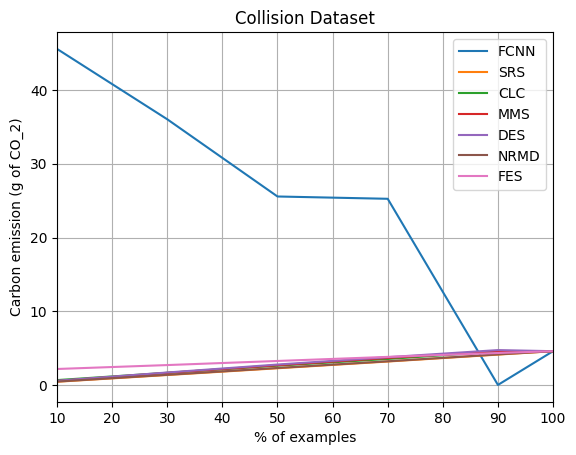

In [23]:
for idx, row in carbon_df.iterrows():
    plt.plot(carbon_df.columns * 100, row, label=idx)
plt.xlabel('% of examples')
plt.ylabel('Carbon emission (g of CO_2)')
plt.title('Collision Dataset')
plt.xlim(10,100)
plt.grid()
plt.legend()
plt.show()

## How $\varepsilon$-representative are the reduced datasets?

In [24]:
epsilon_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        epsilon_df.loc[m][p] = round(median_stats[m][p]['epsilon'],3)
epsilon_df_t = epsilon_df.transpose()
epsilon_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_27848\2445719397.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df.loc[m][p] = round(median_stats[m][p]['epsilon'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.782,0.625,0.529,0.4,0.628,0.959,0.823
0.3,0.815,0.55,0.58,0.332,0.533,0.944,0.67
0.5,0.815,0.55,0.459,0.293,0.533,0.85,0.573
0.7,0.815,0.55,0.419,0.244,0.511,0.754,0.474
0.9,0.979,0.427,0.334,0.22,0.433,0.612,0.392
1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


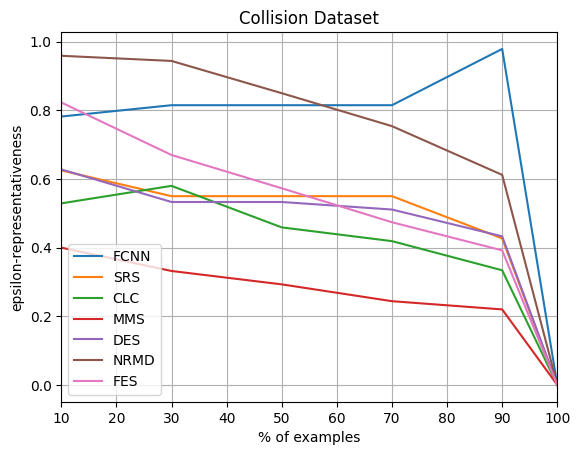

In [25]:
for idx, row in epsilon_df.iterrows():
    plt.plot(epsilon_df.columns * 100, row, label=idx)
plt.xlabel('% of examples')
plt.ylabel('epsilon-representativeness')
plt.title('Collision Dataset')
plt.xlim(10,100)
plt.grid()
plt.legend()
plt.show()

## How does the reduction affect the performance?

In [26]:
accuracy_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        accuracy_df.loc[m][p] = round(median_stats[m][p]['acc'],3)
accuracy_df_t = accuracy_df.transpose()
accuracy_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_27848\2707575944.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df.loc[m][p] = round(median_stats[m][p]['acc'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.905,0.894,0.874,0.865,0.897,0.823,0.646
0.3,0.886,0.895,0.893,0.881,0.896,0.854,0.865
0.5,0.856,0.912,0.892,0.896,0.915,0.862,0.914
0.7,0.854,0.915,0.905,0.902,0.914,0.901,0.918
0.9,0.354,0.911,0.909,0.913,0.916,0.904,0.912
1.0,0.905,0.905,0.905,0.905,0.905,0.905,0.905


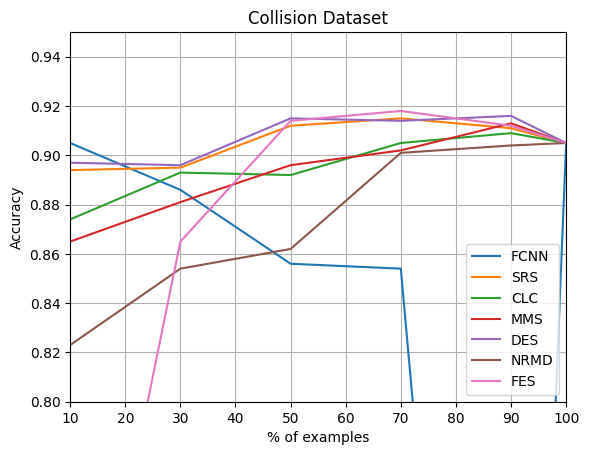

In [27]:
for idx, row in accuracy_df.iterrows():
    plt.plot(accuracy_df.columns * 100, row, label=idx)
plt.xlabel('% of examples')
plt.ylabel('Accuracy')
plt.title('Collision Dataset')
plt.xlim(10,100)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

In [3]:
precision_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        precision_df.loc[m][p] = round(median_stats[m][p]['pre_avg'],3)
precision_df_t = precision_df.transpose()
precision_df_t

NameError: name 'all_methods' is not defined

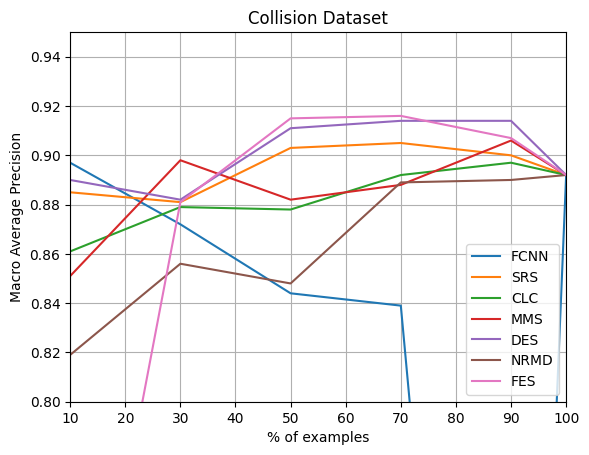

In [29]:
for idx, row in precision_df.iterrows():
    plt.plot(precision_df.columns * 100, row, label=idx)
plt.xlabel('% of examples')
plt.ylabel('Macro Average Precision')
plt.title('Collision Dataset')
plt.xlim(10,100)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

In [2]:
recall_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        recall_df.loc[m][p] = round(median_stats[m][p]['rec_avg'],3)
recall_df_t = recall_df.transpose()
recall_df_t

NameError: name 'all_methods' is not defined

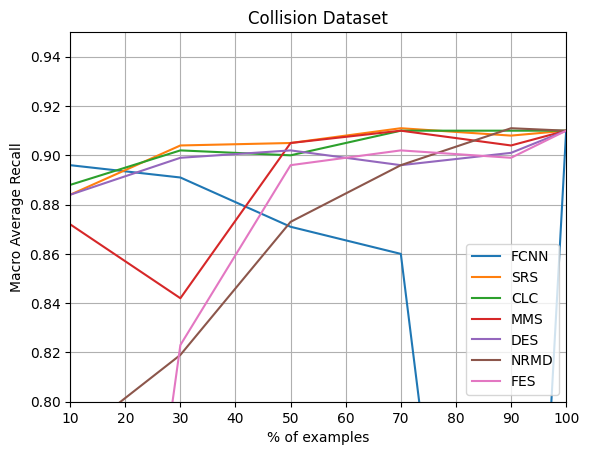

In [31]:
for idx, row in recall_df.iterrows():
    plt.plot(recall_df.columns * 100, row, label=idx)
plt.xlabel('% of examples')
plt.ylabel('Macro Average Recall')
plt.title('Collision Dataset')
plt.xlim(10,100)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

In [32]:
f1score_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        f1score_df.loc[m][p] = round(median_stats[m][p]['f1_avg'],3)
f1score_df_t = f1score_df.transpose()
f1score_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_27848\374755532.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df.loc[m][p] = round(median_stats[m][p]['f1_avg'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.896,0.884,0.868,0.858,0.887,0.796,0.785
0.3,0.879,0.889,0.887,0.861,0.889,0.832,0.842
0.5,0.85,0.904,0.886,0.89,0.906,0.855,0.904
0.7,0.846,0.908,0.899,0.896,0.904,0.893,0.908
0.9,0.523,0.904,0.903,0.905,0.907,0.898,0.903
1.0,0.899,0.899,0.899,0.899,0.899,0.899,0.899


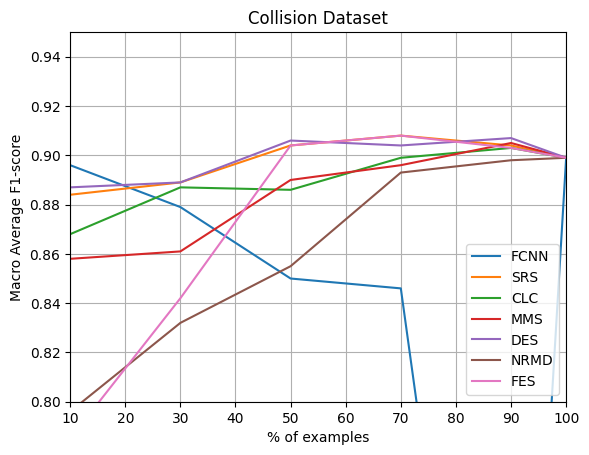

In [33]:
for idx, row in f1score_df.iterrows():
    plt.plot(f1score_df.columns * 100, row, label=idx)
plt.xlabel('% of examples')
plt.ylabel('Macro Average F1-score')
plt.title('Collision Dataset')
plt.xlim(10,100)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

## Does the $\varepsilon$-representativeness affect the performance?

In [34]:
epsilon_acc_df = pd.DataFrame(index=['rho', 'p-value'], columns=percentages[:-1])
for p in percentages[:-1]:
    epsilon_values = []
    accuracy_values = []
    for iter in iterations:
        for m in all_methods:
            # Only add values if both are not None
            if stats[iter][m][p]['epsilon'] is not None and stats[iter][m][p]['acc'] is not None:
                epsilon_values.append(stats[iter][m][p]['epsilon'])
                accuracy_values.append(stats[iter][m][p]['acc'])
    rho, pvalue = spearmanr(epsilon_values, accuracy_values)
    epsilon_acc_df.loc['rho'][p], epsilon_acc_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)
epsilon_acc_df

C:\Users\aless\AppData\Local\Temp\ipykernel_27848\1553345712.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_acc_df.loc['rho'][p], epsilon_acc_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)


,0.1,0.3,0.5,0.7,0.9
rho,-0.25,-0.57,-0.39,-0.39,-0.54
p-value,0.59,0.18,0.38,0.38,0.22


In [35]:
epsilon_f1_df = pd.DataFrame(index=['rho', 'p-value'], columns=percentages[:-1])
for p in percentages[:-1]:
    epsilon_values = []
    f1_values = []
    for iter in iterations:
        for m in all_methods:
            # Only add values if both are not None
            if stats[iter][m][p]['epsilon'] is not None and stats[iter][m][p]['f1_avg'] is not None:
                epsilon_values.append(stats[iter][m][p]['epsilon'])
                f1_values.append(stats[iter][m][p]['f1_avg'])
    rho, pvalue = spearmanr(epsilon_values, f1_values)
    epsilon_f1_df.loc['rho'][p], epsilon_f1_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)
epsilon_f1_df

C:\Users\aless\AppData\Local\Temp\ipykernel_27848\453174950.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_f1_df.loc['rho'][p], epsilon_f1_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)


,0.1,0.3,0.5,0.7,0.9
rho,-0.25,-0.54,-0.39,-0.39,-0.5
p-value,0.59,0.22,0.38,0.38,0.25
